## 1. Data Loading and Preprocessing

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spotify = pd.read_csv('data/raw/tracks.csv')
spotify['year'] = spotify['release_date'].str[:4].astype(int)

spotify_modern = spotify[spotify['year'] >= 2000]
yearly_avg = spotify_modern.groupby('year')[['valence', 'energy', 'danceability', 'mode']].mean()

## 2. Valence Trend Over Time

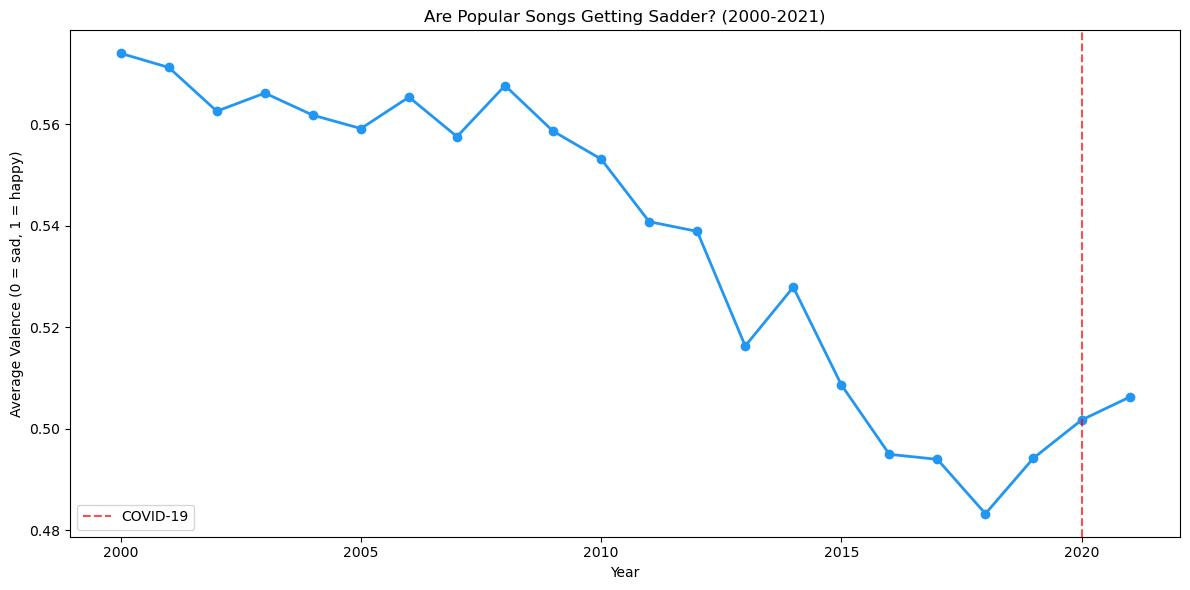

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_avg.index, yearly_avg['valence'], marker='o', linewidth=2, color='#2196F3')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID-19')
ax.set_xlabel('Year')
ax.set_ylabel('Average Valence (0 = sad, 1 = happy)')
ax.set_title('Are Popular Songs Getting Sadder? (2000-2021)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/valence_trend.png', dpi=150)
plt.show()

## 3. Multi-Feature Comparison

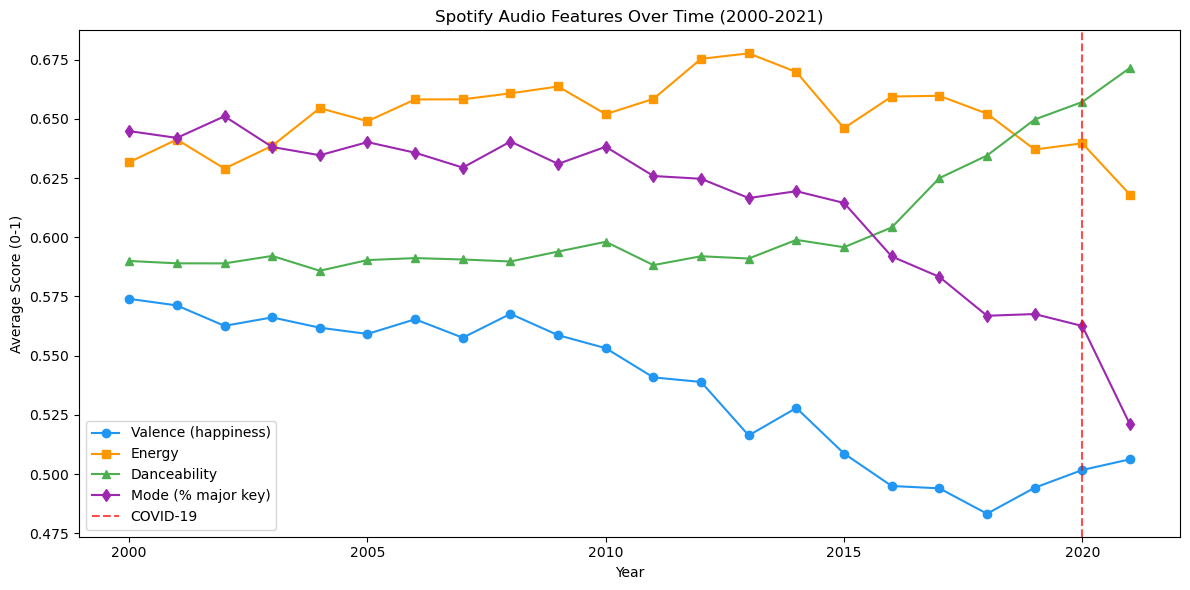

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly_avg.index, yearly_avg['valence'], marker='o', label='Valence (happiness)', color='#2196F3')
ax1.plot(yearly_avg.index, yearly_avg['energy'], marker='s', label='Energy', color='#FF9800')
ax1.plot(yearly_avg.index, yearly_avg['danceability'], marker='^', label='Danceability', color='#4CAF50')
ax1.plot(yearly_avg.index, yearly_avg['mode'], marker='d', label='Mode (% major key)', color='#9C27B0')

ax1.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID-19')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Score (0-1)')
ax1.set_title('Spotify Audio Features Over Time (2000-2021)')
ax1.legend(loc='lower left')
plt.tight_layout()
plt.savefig('figures/multi_feature_trend.png', dpi=150)
plt.show()

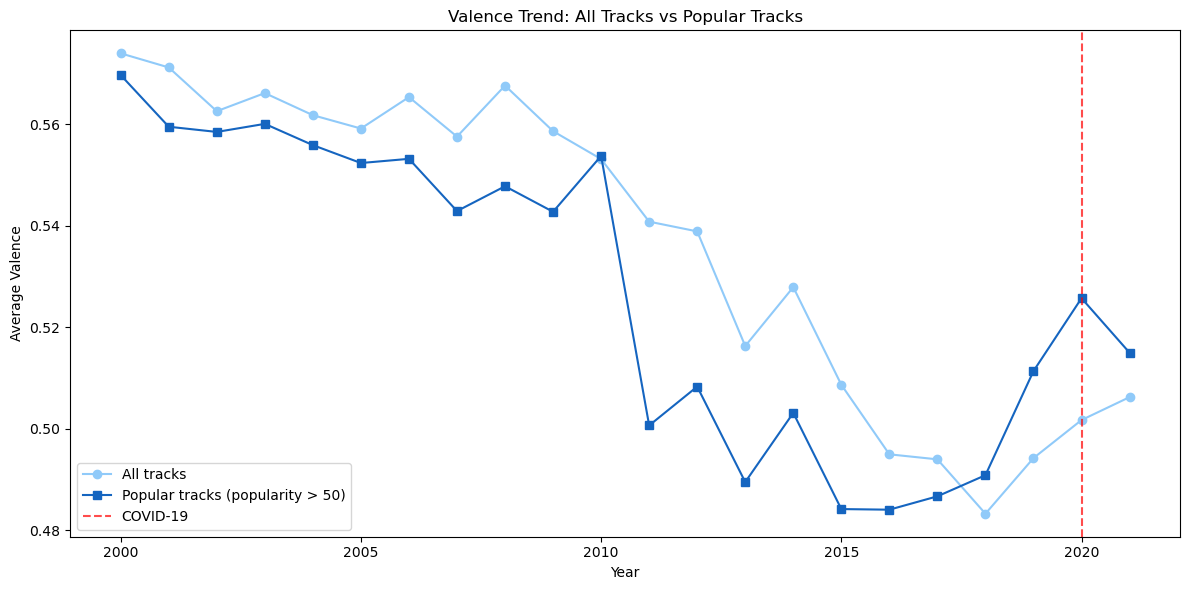

In [11]:
popular = spotify_modern[spotify_modern['popularity'] > 50]
yearly_all = spotify_modern.groupby('year')['valence'].mean()
yearly_pop = popular.groupby('year')['valence'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_all.index, yearly_all.values, marker='o', label='All tracks', color='#90CAF9')
ax.plot(yearly_pop.index, yearly_pop.values, marker='s', label='Popular tracks (popularity > 50)', color='#1565C0')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID-19')
ax.set_xlabel('Year')
ax.set_ylabel('Average Valence')
ax.set_title('Valence Trend: All Tracks vs Popular Tracks')
ax.legend()
plt.tight_layout()
plt.savefig('figures/popular_vs_all.png', dpi=150)
plt.show()

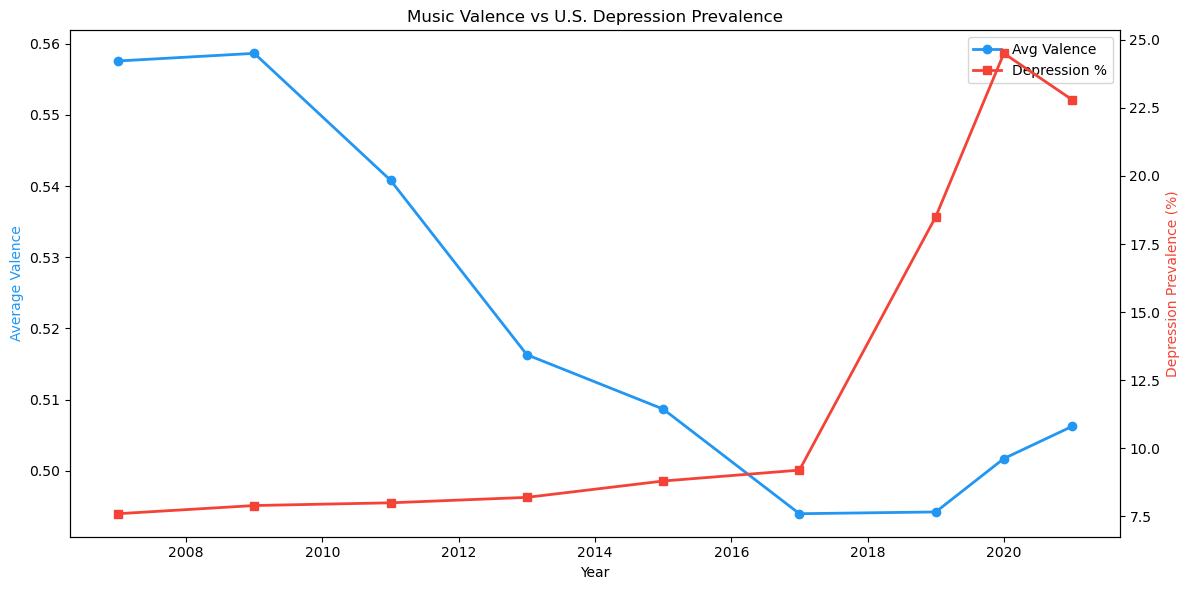

Pearson correlation (valence vs depression): r = -0.570


In [12]:
mental = pd.read_csv('data/raw/us_mental_health_trends.csv')

yearly_valence = spotify_modern.groupby('year')['valence'].mean().reset_index()
yearly_valence.columns = ['year', 'avg_valence']

merged = pd.merge(yearly_valence, mental[['year', 'depression_pct']], on='year', how='inner')
merged = merged.dropna(subset=['depression_pct'])

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(merged['year'], merged['avg_valence'], 'o-', color='#2196F3', linewidth=2, label='Avg Valence')
ax2.plot(merged['year'], merged['depression_pct'], 's-', color='#F44336', linewidth=2, label='Depression %')

ax1.set_xlabel('Year')
ax1.set_ylabel('Average Valence', color='#2196F3')
ax2.set_ylabel('Depression Prevalence (%)', color='#F44336')
ax1.set_title('Music Valence vs U.S. Depression Prevalence')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('figures/valence_vs_depression.png', dpi=150)
plt.show()

corr = merged['avg_valence'].corr(merged['depression_pct'])
print(f"Pearson correlation (valence vs depression): r = {corr:.3f}")

In [13]:
from scipy import stats

pre_covid = spotify_modern[spotify_modern['year'] < 2020]['valence']
post_covid = spotify_modern[spotify_modern['year'] >= 2020]['valence']

t_stat, p_value = stats.ttest_ind(pre_covid, post_covid)

print(f"Pre-COVID mean valence:  {pre_covid.mean():.4f}")
print(f"Post-COVID mean valence: {post_covid.mean():.4f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Significant at 0.05 level: {p_value < 0.05}")

Pre-COVID mean valence:  0.5368
Post-COVID mean valence: 0.5031
t-statistic: 18.128
p-value: 0.000000
Significant at 0.05 level: True
